# Notebook 10 — Mixture Fraction: 1-D Counterflow Diffusion Flame

This notebook demonstrates the mixture-fraction approach to non-premixed combustion
using uPDE's `MixtureFraction` equation factory and the `FlameletTable` chemistry class.

## Physical setup

A fuel stream (CH₄, $Z=1$) and an air stream ($Z=0$) are separated at $t=0$ and diffuse
toward each other in a 1-D domain $x \in [0, 1]$.  The governing equation is:

$$\frac{\partial Z}{\partial t} = D \frac{\partial^2 Z}{\partial x^2}$$

with Dirichlet boundary conditions:

$$Z(0,t) = 0 \quad (\text{air}), \qquad Z(1,t) = 1 \quad (\text{fuel})$$

The steady-state solution is simply $Z(x) = x$.  The flame lives at the stoichiometric
surface $Z = Z_{\mathrm{st}} \approx 0.055$ for CH₄/air.

## Key idea

uPDE solves only the **transport** equation for $Z$ — a pure convection-diffusion problem
with no stiff chemistry.  Temperature and species are reconstructed *after* the solve by
passing $Z$ through the `FlameletTable` (a simple `numpy.interp` call).  The chemical
stiffness is entirely absent from the ODE system passed to `solve_ivp`.

No external dependencies are needed — the analytic Burke-Schumann table is used.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from upde import MixtureFraction, PDESystem
from upde.chemistry import FlameletTable

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

## 1. Build the flamelet table

The Burke-Schumann table gives the analytic equilibrium solution for CH₄/air combustion.
It maps $Z \in [0,1]$ to temperature and species mass fractions using piecewise-linear
profiles that peak at the stoichiometric mixture fraction $Z_{\mathrm{st}}$.

In [2]:
Z_st = 0.055        # stoichiometric mixture fraction for CH4/air
T_ad = 2230.0       # adiabatic flame temperature [K]
T_fuel, T_ox = 300.0, 300.0

table = FlameletTable.burke_schumann(
    Z_st=Z_st, T_fuel=T_fuel, T_ox=T_ox, T_ad=T_ad
)
print(table)

FlameletTable(n=500, Z=[0.000,1.000], T=[300,2228]K, species=['CH4', 'O2', 'CO2', 'H2O', 'N2'])


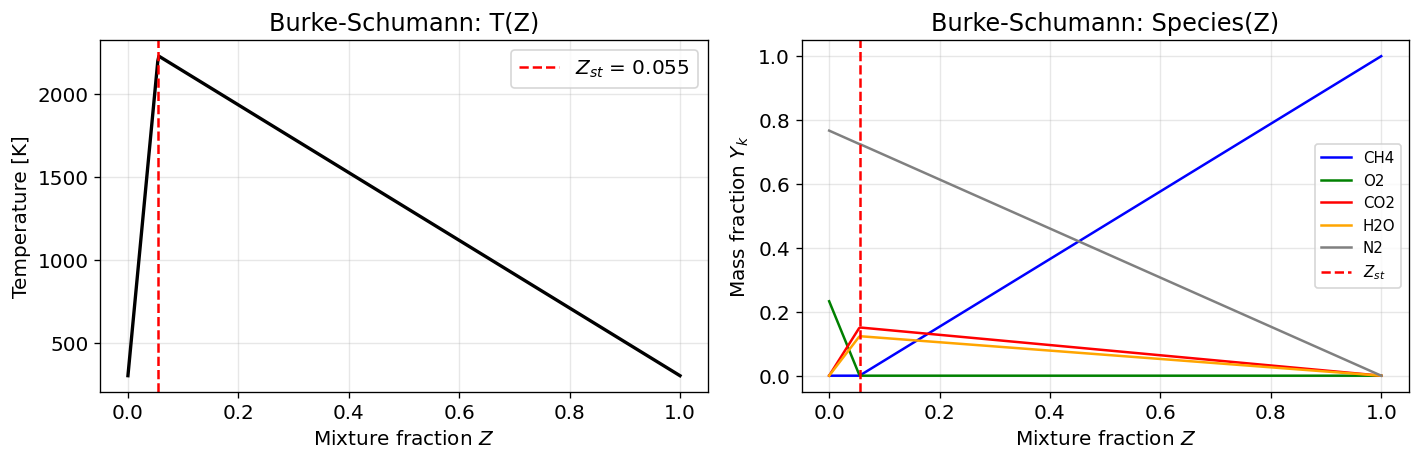

In [3]:
# Inspect the table: T and Y_k as functions of Z
Z_plot = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(Z_plot, table.T(Z_plot), 'k-', lw=2)
ax.axvline(Z_st, color='red', ls='--', label=f'$Z_{{st}}$ = {Z_st}')
ax.set_xlabel('Mixture fraction $Z$')
ax.set_ylabel('Temperature [K]')
ax.set_title('Burke-Schumann: T(Z)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = {'CH4': 'blue', 'O2': 'green', 'CO2': 'red', 'H2O': 'orange', 'N2': 'gray'}
for sp in table.species:
    ax.plot(Z_plot, table.Y(sp, Z_plot), label=sp, color=colors.get(sp, 'black'))
ax.axvline(Z_st, color='red', ls='--', label=f'$Z_{{st}}$')
ax.set_xlabel('Mixture fraction $Z$')
ax.set_ylabel('Mass fraction $Y_k$')
ax.set_title('Burke-Schumann: Species(Z)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig10_flamelet_table.png', bbox_inches='tight')
plt.show()

## 2. Solve the mixture-fraction transport equation

The `MixtureFraction` factory builds an `AdvectionDiffusion` equation for $Z$.
Without advection, this reduces to the heat equation — we solve to steady state.

In [4]:
nx = 256
x  = np.linspace(0.0, 1.0, nx)
D  = 1e-4   # molecular diffusivity [m²/s]

eq = MixtureFraction('Z', x=x, diffusivity=D)

# Boundary conditions: air at left, fuel at right
eq.set_bc(side='left',  kind='dirichlet', value=0.0)   # Z = 0: oxidiser
eq.set_bc(side='right', kind='dirichlet', value=1.0)   # Z = 1: fuel

# Initial condition: step function — fuel and air initially separated
eq.set_ic(lambda x: (x > 0.5).astype(float))

# Solve to steady state: diffusion time scale ~ L²/D = 1/1e-4 = 10000 s
# Use t_end >> diffusion time to reach steady state
t_end   = 20000.0
t_store = np.linspace(0, t_end, 100)

sol = PDESystem([eq]).solve(
    t_span=(0, t_end),
    t_eval=t_store,
    method='BDF',
    rtol=1e-6, atol=1e-8,
)
print(f'Solve success: {sol.success}  |  {sol.message}')
print(f'Z range at final time: [{sol.Z[:,-1].min():.4f}, {sol.Z[:,-1].max():.4f}]')

Solve success: True  |  The solver successfully reached the end of the integration interval.
Z range at final time: [-0.0000, 1.0000]


## 3. Reconstruct temperature and species from the flamelet table

The solve gave us $Z(x,t)$.  We now evaluate $T(Z)$ and $Y_k(Z)$ at every
spatial location — just `numpy.interp` calls, taking microseconds.

In [5]:
# Reconstruct at every stored time
T_field   = table.T(sol.Z)           # shape (nx, nt)
Y_CH4     = table.Y('CH4', sol.Z)
Y_O2      = table.Y('O2',  sol.Z)
Y_CO2     = table.Y('CO2', sol.Z)
Y_H2O     = table.Y('H2O', sol.Z)
Y_N2      = table.Y('N2',  sol.Z)

print(f'Peak temperature at final time: {T_field[:,-1].max():.1f} K')
print(f'Expected adiabatic flame temp:  {T_ad:.1f} K')
print(f'Flame location (peak T):        x = {x[np.argmax(T_field[:,-1])]:.4f}')
print(f'Expected (Z_st = {Z_st}):          x = {Z_st:.4f}')

Peak temperature at final time: 2222.2 K
Expected adiabatic flame temp:  2230.0 K
Flame location (peak T):        x = 0.0588
Expected (Z_st = 0.055):          x = 0.0550


/var/folders/1h/j4vfstmd0mg9l3bbtrzyr21r0000gn/T/ipykernel_25534/269734344.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


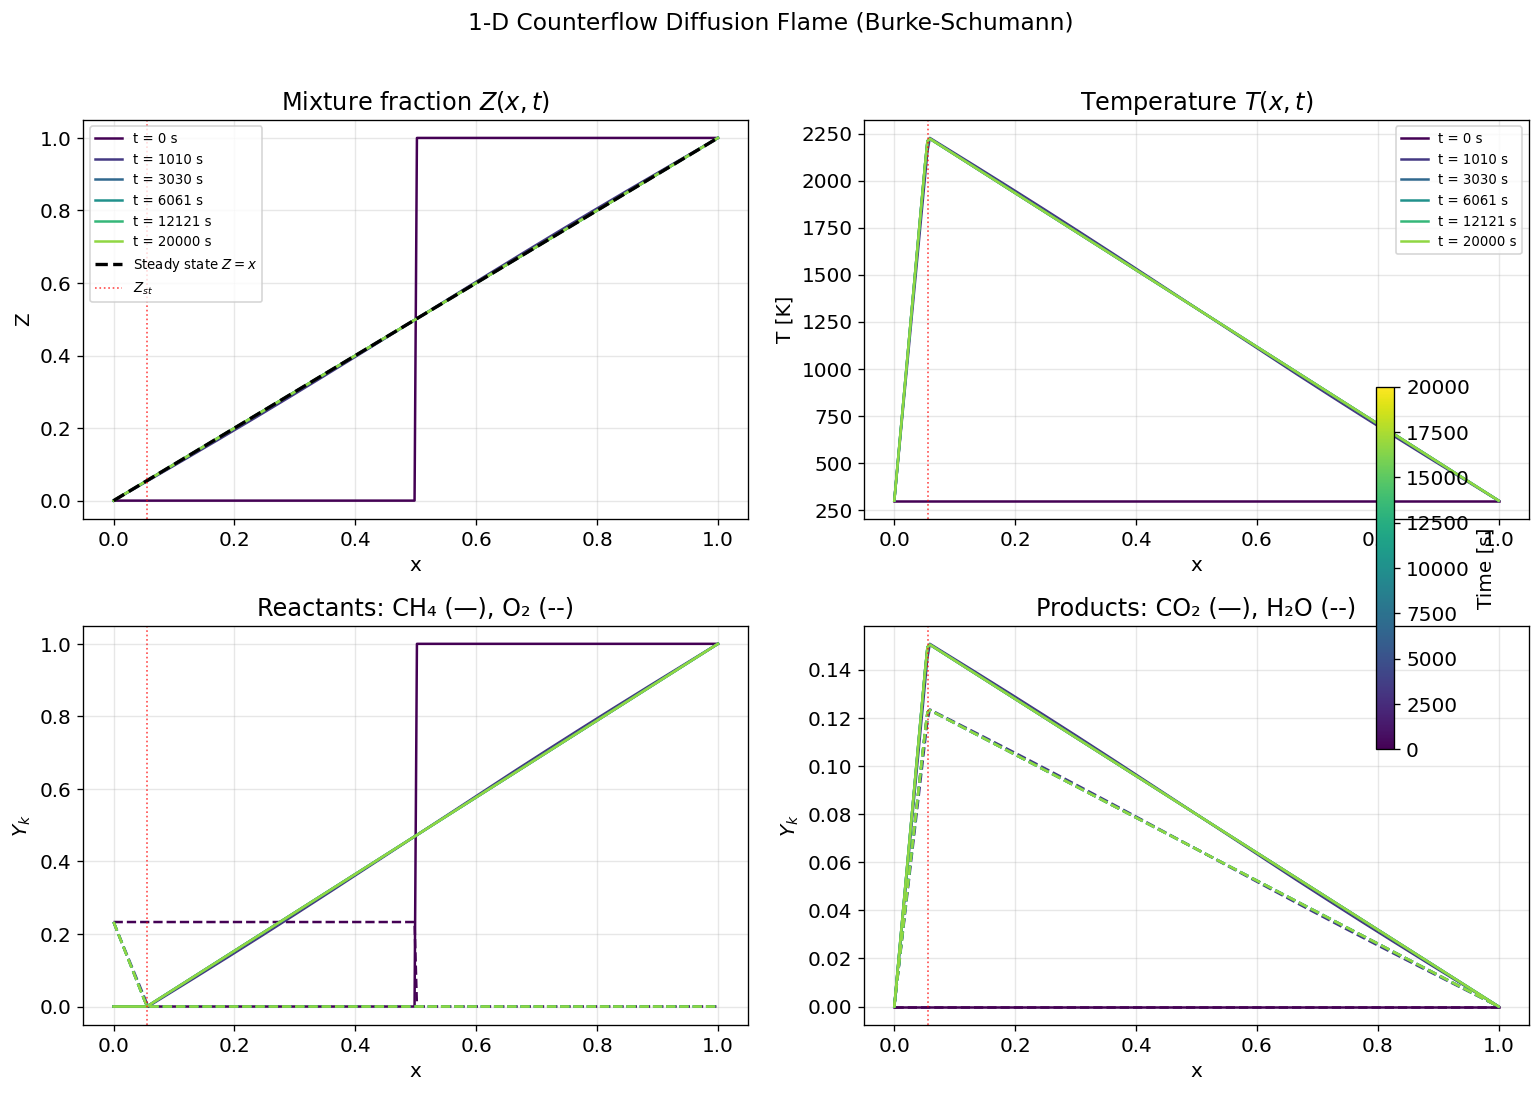

In [6]:
# Plot Z, T, and species at several times
t_indices = [0, 5, 15, 30, 60, 99]   # time snapshot indices
cmap = plt.cm.viridis
colors_t = [cmap(i/len(t_indices)) for i in range(len(t_indices))]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for i, idx in enumerate(t_indices):
    t_val = sol.t[idx]
    label = f't = {t_val:.0f} s'
    c = colors_t[i]

    axes[0,0].plot(x, sol.Z[:,idx],     color=c, label=label)
    axes[0,1].plot(x, T_field[:,idx],   color=c, label=label)
    axes[1,0].plot(x, Y_CH4[:,idx],     color=c, label=label)
    axes[1,0].plot(x, Y_O2[:,idx],      color=c, ls='--')
    axes[1,1].plot(x, Y_CO2[:,idx],     color=c, label=label)
    axes[1,1].plot(x, Y_H2O[:,idx],     color=c, ls='--')

# Steady-state analytical Z = x
axes[0,0].plot(x, x, 'k--', lw=2, label='Steady state $Z=x$')

# Flame location
for ax in axes.flat:
    ax.axvline(Z_st, color='red', ls=':', lw=1, alpha=0.7, label='$Z_{st}$' if ax is axes[0,0] else None)

axes[0,0].set(xlabel='x', ylabel='Z', title='Mixture fraction $Z(x,t)$')
axes[0,1].set(xlabel='x', ylabel='T [K]', title='Temperature $T(x,t)$')
axes[1,0].set(xlabel='x', ylabel='$Y_k$', title='Reactants: CH₄ (—), O₂ (--)')
axes[1,1].set(xlabel='x', ylabel='$Y_k$', title='Products: CO₂ (—), H₂O (--)')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

axes[0,0].legend(fontsize=8, loc='upper left')
axes[0,1].legend(fontsize=8)

# Colorbar for time
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, t_end))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Time [s]', fraction=0.015, pad=0.04)

plt.suptitle('1-D Counterflow Diffusion Flame (Burke-Schumann)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig10_counterflow_flame_1d.png', bbox_inches='tight')
plt.show()

## 4. Steady-state profiles

At steady state, $Z(x) = x$ exactly (linear diffusion profile between two Dirichlet walls).
The flame sits at $x = Z_{\mathrm{st}} \approx 0.055$ — very close to the air-side wall, 
because methane requires a large amount of air (stoichiometric air-fuel ratio ≈ 17.2 by mass).

We verify the steady-state solution and check against the analytical result.

Max |Z_numerical - Z_exact| at steady state: 8.15e-10


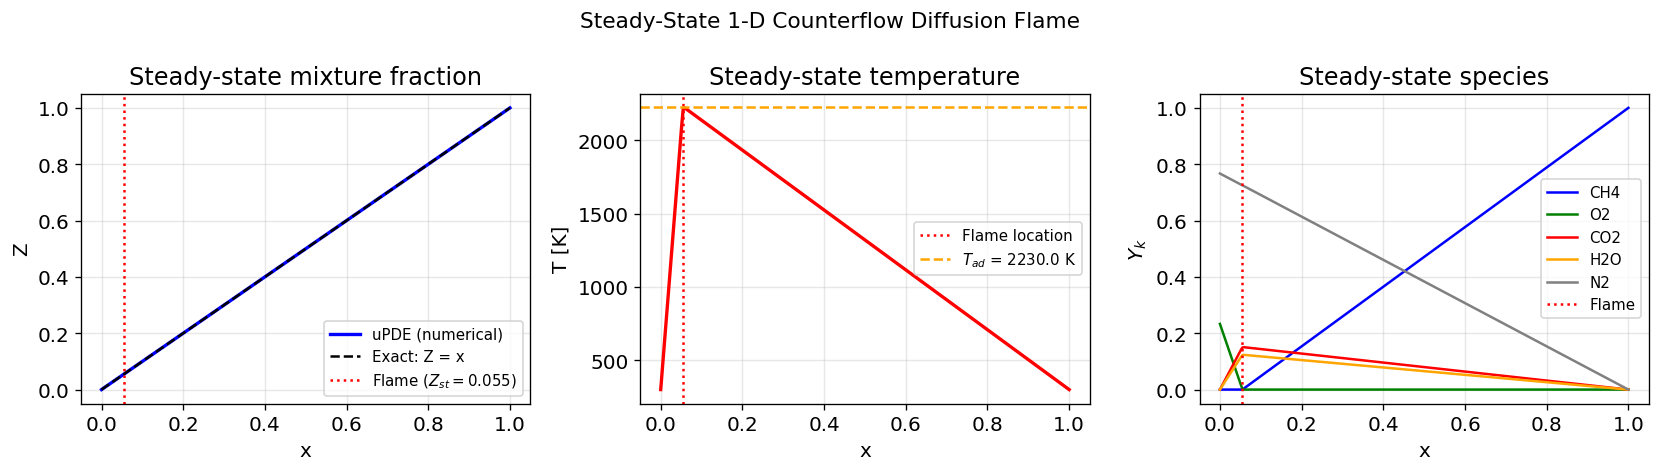

In [7]:
Z_final  = sol.Z[:, -1]
T_final  = T_field[:, -1]
Z_exact  = x    # analytical steady state

err = np.max(np.abs(Z_final - Z_exact))
print(f'Max |Z_numerical - Z_exact| at steady state: {err:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(x, Z_final, 'b-', lw=2, label='uPDE (numerical)')
ax.plot(x, Z_exact, 'k--', lw=1.5, label='Exact: Z = x')
ax.axvline(Z_st, color='red', ls=':', label=f'Flame ($Z_{{st}}={Z_st}$)')
ax.set(xlabel='x', ylabel='Z', title='Steady-state mixture fraction')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, T_final, 'r-', lw=2)
ax.axvline(Z_st, color='red', ls=':', label=f'Flame location')
ax.axhline(T_ad, color='orange', ls='--', label=f'$T_{{ad}}$ = {T_ad} K')
ax.set(xlabel='x', ylabel='T [K]', title='Steady-state temperature')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
for sp, col in colors.items():
    ax.plot(x, table.Y(sp, Z_final), color=col, label=sp, lw=1.5)
ax.axvline(Z_st, color='red', ls=':', label='Flame')
ax.set(xlabel='x', ylabel='$Y_k$', title='Steady-state species')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Steady-State 1-D Counterflow Diffusion Flame', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_steady_state_1d.png', bbox_inches='tight')
plt.show()

## 5. Adding convection: moving flame

Now we add a mean convective flow $u$ to see how advection shifts the flame.
With advection, the steady-state $Z$ profile is exponential rather than linear,
and the flame shifts toward the fuel or oxidiser side depending on the flow direction.

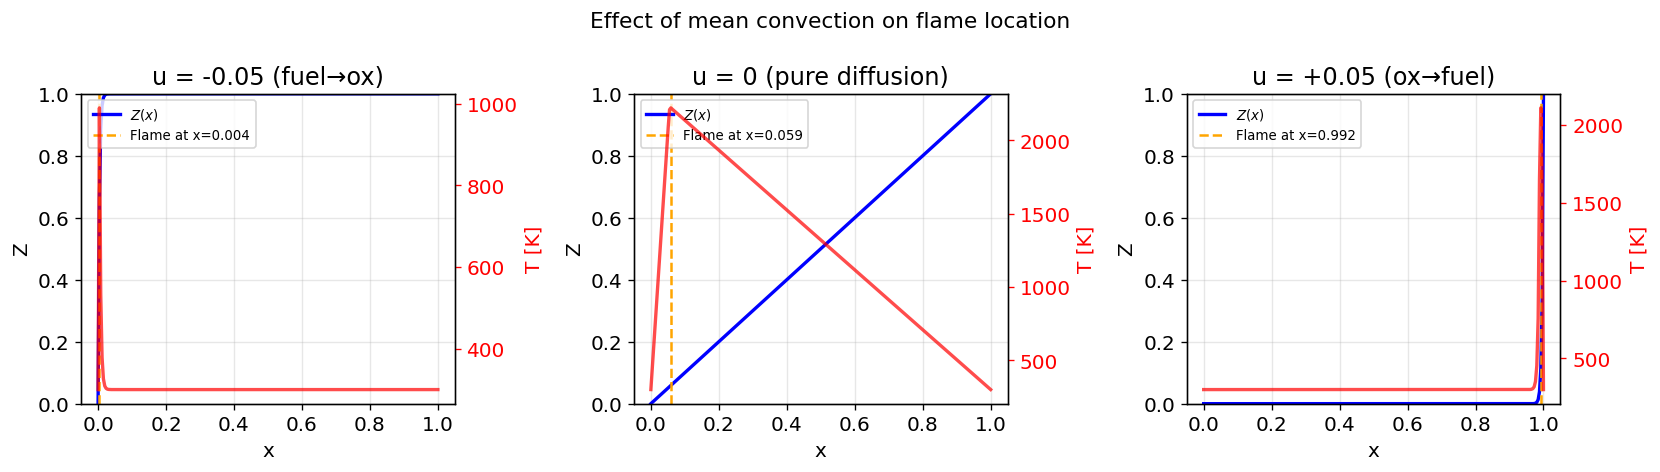

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, u_val, label in zip(
    axes,
    [-0.05, 0.0, 0.05],
    ['u = -0.05 (fuel→ox)', 'u = 0 (pure diffusion)', 'u = +0.05 (ox→fuel)']
):
    eq_c = MixtureFraction('Z', x=x, velocity=u_val, diffusivity=D)
    eq_c.set_bc(side='left',  kind='dirichlet', value=0.0)
    eq_c.set_bc(side='right', kind='dirichlet', value=1.0)
    eq_c.set_ic(lambda x: x)   # start near steady state

    sol_c = PDESystem([eq_c]).solve(
        t_span=(0, 30000),
        method='BDF', rtol=1e-6, atol=1e-8,
    )
    Z_ss = sol_c.Z[:, -1]
    T_ss = table.T(Z_ss)

    ax.plot(x, Z_ss, 'b-', lw=2, label='$Z(x)$')
    ax_t = ax.twinx()
    ax_t.plot(x, T_ss, 'r-', lw=2, alpha=0.7, label='$T(x)$ [K]')
    ax_t.set_ylabel('T [K]', color='red')
    ax_t.tick_params(axis='y', colors='red')

    x_flame = x[np.argmax(T_ss)]
    ax.axvline(x_flame, color='orange', ls='--',
               label=f'Flame at x={x_flame:.3f}')
    ax.set(xlabel='x', ylabel='Z', title=label)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Effect of mean convection on flame location', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_convection_effect.png', bbox_inches='tight')
plt.show()

## 6. Saving and reloading the flamelet table

Tables can be saved as `.npz` files for reuse — no recomputation needed.
If Cantera is installed, `from_cantera()` can generate a high-fidelity table
and save it the same way.

In [9]:
# Save the table
table.save('ch4_air_burke_schumann.npz')

# Reload and verify
table2 = FlameletTable.from_file('ch4_air_burke_schumann.npz')
print(table2)

# Check round-trip accuracy
Z_test = np.linspace(0, 1, 100)
err_T  = np.max(np.abs(table.T(Z_test) - table2.T(Z_test)))
print(f'Max round-trip error in T: {err_T:.2e} K  ✓')

# --- Using Cantera (optional) ---
print("\nTo generate a high-fidelity Cantera table (requires 'pip install cantera'):")
print("  table = FlameletTable.from_cantera('gri30.yaml', fuel='CH4')")
print("  table.save('ch4_air_gri30.npz')")

FlameletTable(n=500, Z=[0.000,1.000], T=[300,2228]K, species=['CH4', 'O2', 'CO2', 'H2O', 'N2'])
Max round-trip error in T: 0.00e+00 K  ✓

To generate a high-fidelity Cantera table (requires 'pip install cantera'):
  table = FlameletTable.from_cantera('gri30.yaml', fuel='CH4')
  table.save('ch4_air_gri30.npz')


## Summary

| Step | What uPDE does | What the user does |
|------|---------------|--------------------|
| Build chemistry table | — | `FlameletTable.burke_schumann()` or `from_cantera()` |
| Set up Z transport | `MixtureFraction(...)` | Set BCs and IC |
| Solve (no stiff chemistry!) | `PDESystem.solve()` via `solve_ivp` | Choose `method='BDF'` |
| Reconstruct T, Y_k | — | `table.T(sol.Z)`, `table.Y('CH4', sol.Z)` |

**Key advantage:** the ODE passed to `solve_ivp` contains only diffusion — the stiff
chemistry timescales are entirely absent.  `method='BDF'` handles 1-D diffusion easily
even on fine grids.